In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import operator
import math
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
data = load_breast_cancer()

In [3]:
data

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [4]:
df = pd.DataFrame(data.data, columns=data.feature_names)

In [5]:
df['target'] = data.target

# Zapoznanie ze zbiorem danych

In [6]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

In [7]:
data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [8]:
df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440,0
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368,0
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510,0
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720,0
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750,0


In [9]:
df.head(10).T

,0,1,2,3,4,5,6,7,8,9
mean radius,17.990000,20.570000,19.690000,11.420000,20.290000,12.450000,18.250000,13.710000,13.000000,12.460000
mean texture,10.380000,17.770000,21.250000,20.380000,14.340000,15.700000,19.980000,20.830000,21.820000,24.040000
mean perimeter,122.800000,132.900000,130.000000,77.580000,135.100000,82.570000,119.600000,90.200000,87.500000,83.970000
mean area,1001.000000,1326.000000,1203.000000,386.100000,1297.000000,477.100000,1040.000000,577.900000,519.800000,475.900000
mean smoothness,0.118400,0.084740,0.109600,0.142500,0.100300,0.127800,0.094630,0.118900,0.127300,0.118600
mean compactness,0.277600,0.078640,0.159900,0.283900,0.132800,0.170000,0.109000,0.164500,0.193200,0.239600
mean concavity,0.300100,0.086900,0.197400,0.241400,0.198000,0.157800,0.112700,0.093660,0.185900,0.227300
mean concave points,0.147100,0.070170,0.127900,0.105200,0.104300,0.080890,0.074000,0.059850,0.093530,0.085430
mean symmetry,0.241900,0.181200,0.206900,0.259700,0.180900,0.208700,0.179400,0.219600,0.235000,0.203000
mean fractal dimension,0.078710,0.056670,0.059990,0.097440,0.058830,0.076130,0.057420,0.074510,0.073890,0.082430


In [10]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [12]:
df.describe(include='all')

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [13]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [14]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [15]:
df.shape

(569, 31)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [17]:
df.dtypes

mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst symmetry      

In [18]:
df.columns.tolist()

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

# Metody badania, które cechy w zbiorze danych mają największy wpływ na ostateczny wynik, czyli które cechy wpływają najbardziej na rozpoznanie przez model zmiennej docelowej (target)

## 1. Random Forest - dzięki temu modelowi można sprawdzić ważność cech, dzięki feature_importances

In [19]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
model_random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
model_random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Wyniki modelu Random Forest są dość dobre, bo skuteczność wynosi aż 96%. Macierz pomyłek wskazuje na 40 przypadków poprawnie odgadniętych przypadków nowotworów złośliwych, 3 przypadki przeoczone nowotwory złośliwe (sklasyfikowane jako łagodne) oraz 70 przypadków odgadniętych nowotworów łagodnych i 1 przypadek błędny uznany za złośliwy, chociaż przypadek był łagodny.

In [21]:
y_pred_random_forest = model_random_forest.predict(X_test)

print('Dokładność (Accuracy Score):', accuracy_score(y_test, y_pred_random_forest))
print('Macierz pomyłek (Confusion Matrix):', confusion_matrix(y_test, y_pred_random_forest))
print('Raport', classification_report(y_test, y_pred_random_forest))

Dokładność (Accuracy Score): 0.9649122807017544
Macierz pomyłek (Confusion Matrix): [[40  3]
 [ 1 70]]
Raport               precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



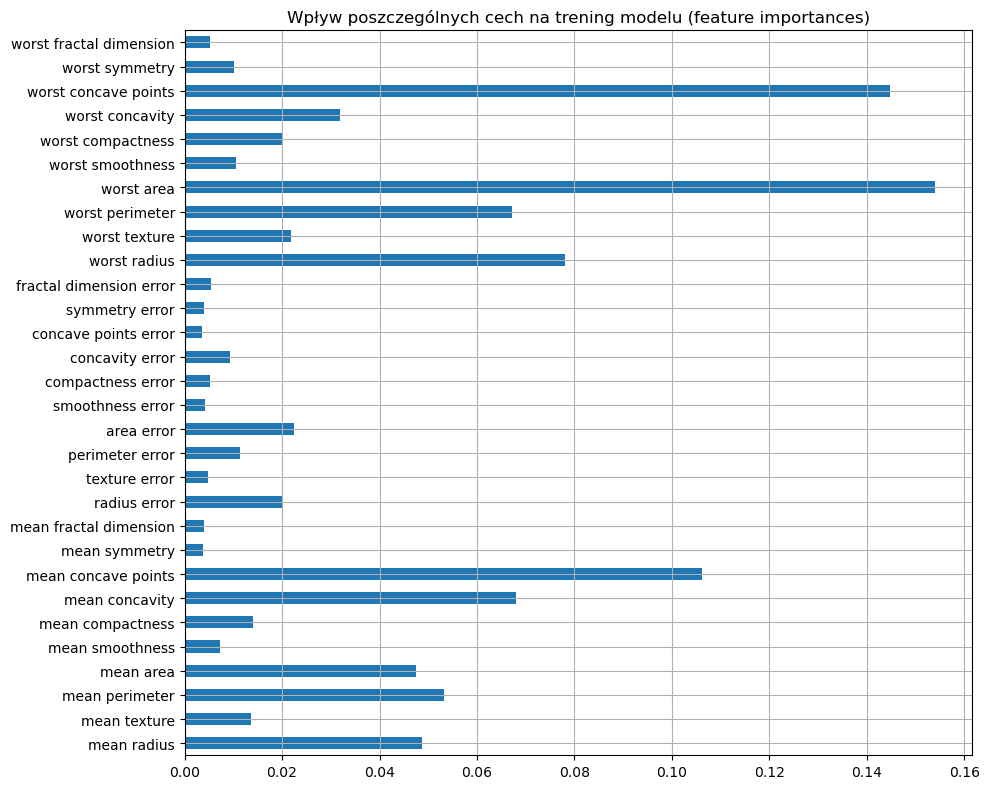

In [22]:
forest_importances = pd.Series(model_random_forest.feature_importances_, index=X.columns)

fig, ax = plt.subplots(figsize=(10, 8))

forest_importances.plot.barh()
ax.set_title('Wpływ poszczególnych cech na trening modelu (feature importances)')
ax.grid()
plt.tight_layout()
plt.show()

In [23]:
feature_importances_values = dict(zip(X.columns, model_random_forest.feature_importances_))
feature_importances_values

{'mean radius': 0.048703371737755234,
 'mean texture': 0.013590877656998469,
 'mean perimeter': 0.053269746128179675,
 'mean area': 0.04755500886018552,
 'mean smoothness': 0.007285327830663239,
 'mean compactness': 0.013944325074050485,
 'mean concavity': 0.06800084191430111,
 'mean concave points': 0.10620998844591638,
 'mean symmetry': 0.003770291819290666,
 'mean fractal dimension': 0.0038857721093275,
 'radius error': 0.02013891719419153,
 'texture error': 0.004723988073894702,
 'perimeter error': 0.01130301388178435,
 'area error': 0.022406960160458473,
 'smoothness error': 0.004270910110504497,
 'compactness error': 0.005253215538990106,
 'concavity error': 0.009385832251596627,
 'concave points error': 0.003513255105598506,
 'symmetry error': 0.004018418617722808,
 'fractal dimension error': 0.00532145634222884,
 'worst radius': 0.07798687515738047,
 'worst texture': 0.021749011006763207,
 'worst perimeter': 0.06711483267839194,
 'worst area': 0.15389236463205394,
 'worst smoot

In [24]:
# https://stackoverflow.com/questions/20577840/python-dictionary-sorting-in-descending-order-based-on-values
feature_importances_values_sorted_desc = sorted(feature_importances_values.items(), key=operator.itemgetter(1), reverse=True)
feature_importances_values_sorted_desc

[('worst area', 0.15389236463205394),
 ('worst concave points', 0.14466326620735528),
 ('mean concave points', 0.10620998844591638),
 ('worst radius', 0.07798687515738047),
 ('mean concavity', 0.06800084191430111),
 ('worst perimeter', 0.06711483267839194),
 ('mean perimeter', 0.053269746128179675),
 ('mean radius', 0.048703371737755234),
 ('mean area', 0.04755500886018552),
 ('worst concavity', 0.031801595740040434),
 ('area error', 0.022406960160458473),
 ('worst texture', 0.021749011006763207),
 ('worst compactness', 0.020266035899623565),
 ('radius error', 0.02013891719419153),
 ('mean compactness', 0.013944325074050485),
 ('mean texture', 0.013590877656998469),
 ('perimeter error', 0.01130301388178435),
 ('worst smoothness', 0.010644205147280952),
 ('worst symmetry', 0.010120176131974357),
 ('concavity error', 0.009385832251596627),
 ('mean smoothness', 0.007285327830663239),
 ('fractal dimension error', 0.00532145634222884),
 ('compactness error', 0.005253215538990106),
 ('worst 

In [25]:
for x in range(len(feature_importances_values_sorted_desc)):
    print(f'Wpływ cechy: \'{feature_importances_values_sorted_desc[x][0]}\' na model wynosi {(feature_importances_values_sorted_desc[x][1]*100):.2f} %.')

Wpływ cechy: 'worst area' na model wynosi 15.39 %.
Wpływ cechy: 'worst concave points' na model wynosi 14.47 %.
Wpływ cechy: 'mean concave points' na model wynosi 10.62 %.
Wpływ cechy: 'worst radius' na model wynosi 7.80 %.
Wpływ cechy: 'mean concavity' na model wynosi 6.80 %.
Wpływ cechy: 'worst perimeter' na model wynosi 6.71 %.
Wpływ cechy: 'mean perimeter' na model wynosi 5.33 %.
Wpływ cechy: 'mean radius' na model wynosi 4.87 %.
Wpływ cechy: 'mean area' na model wynosi 4.76 %.
Wpływ cechy: 'worst concavity' na model wynosi 3.18 %.
Wpływ cechy: 'area error' na model wynosi 2.24 %.
Wpływ cechy: 'worst texture' na model wynosi 2.17 %.
Wpływ cechy: 'worst compactness' na model wynosi 2.03 %.
Wpływ cechy: 'radius error' na model wynosi 2.01 %.
Wpływ cechy: 'mean compactness' na model wynosi 1.39 %.
Wpływ cechy: 'mean texture' na model wynosi 1.36 %.
Wpływ cechy: 'perimeter error' na model wynosi 1.13 %.
Wpływ cechy: 'worst smoothness' na model wynosi 1.06 %.
Wpływ cechy: 'worst symmetr

### Boxploty przedstawiające wpływ poszczególnych cech na odgadnięcie zmiennej docelowej: target

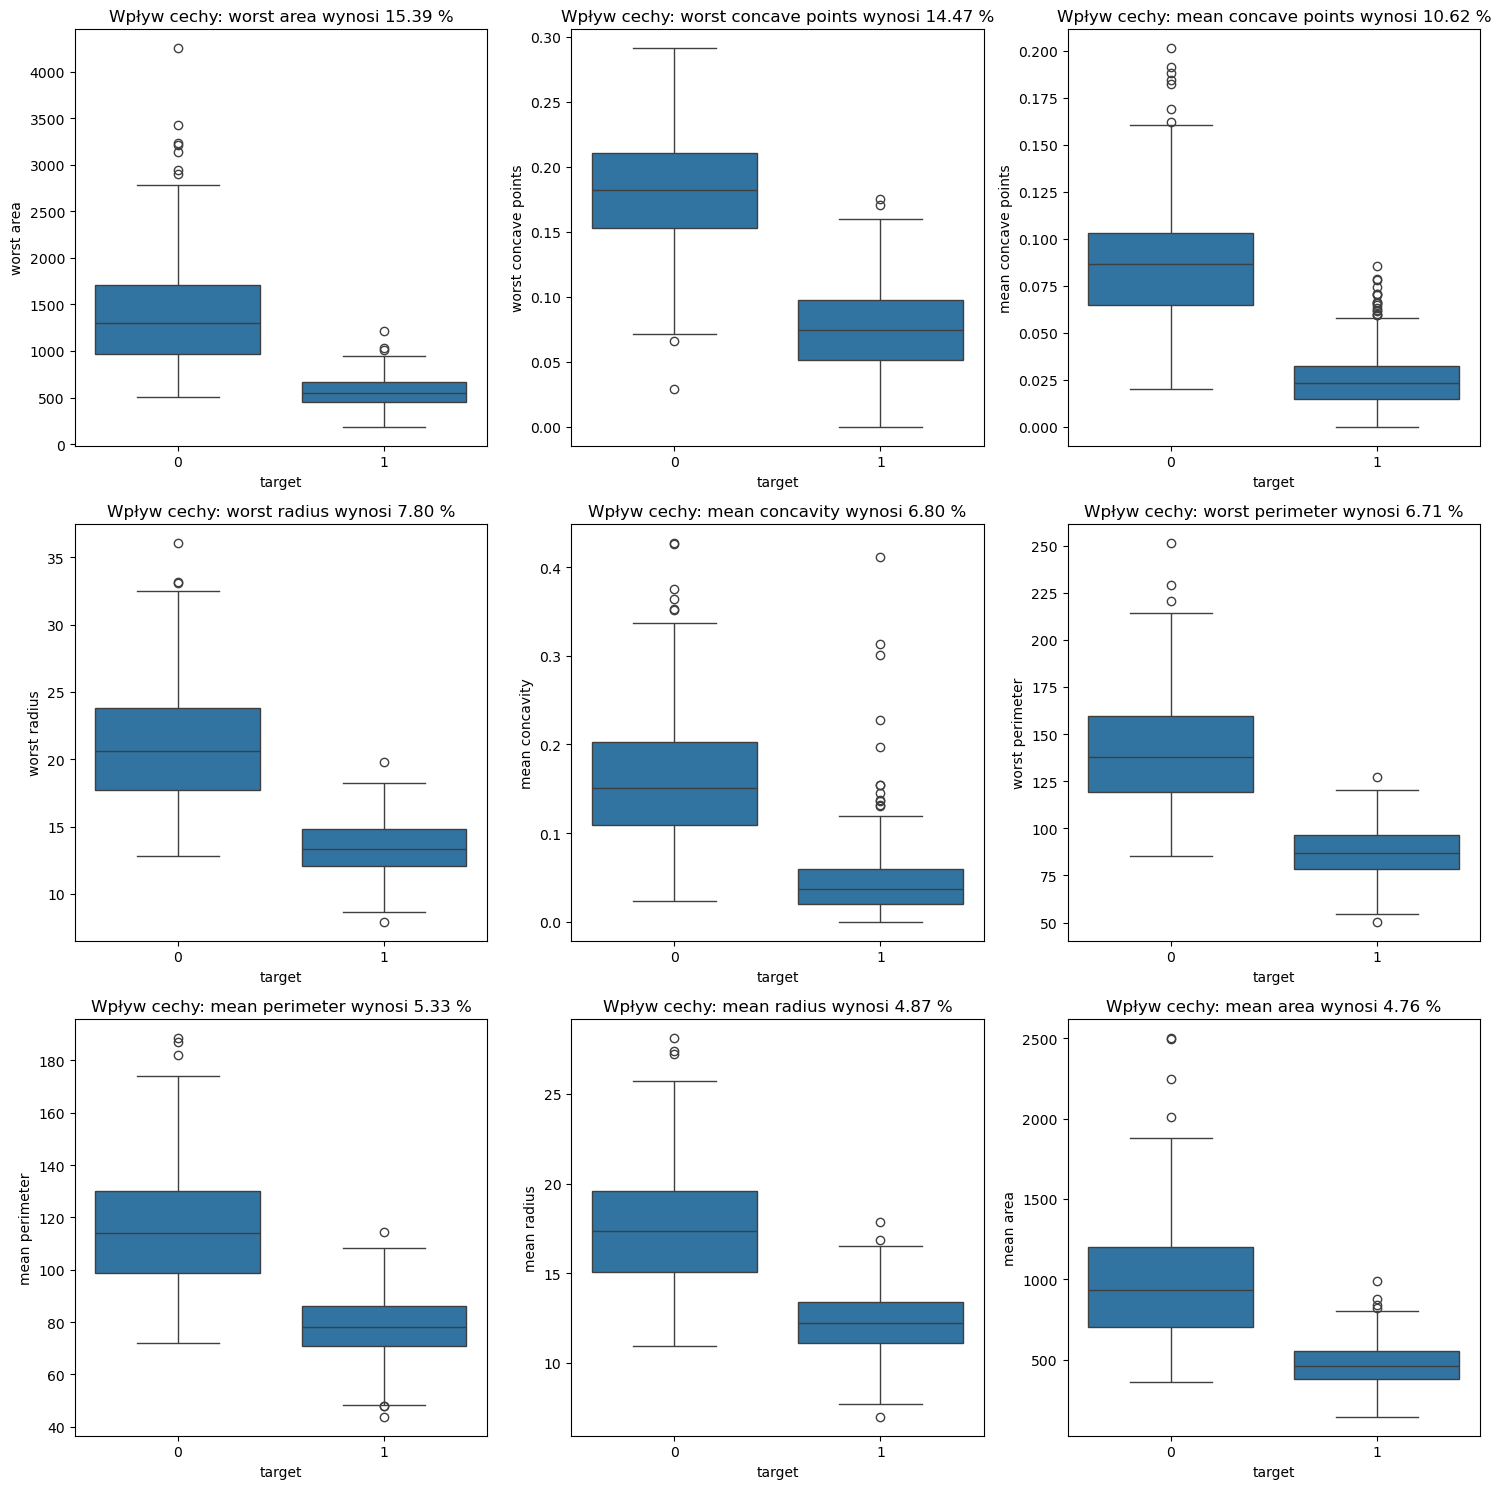

In [26]:
# https://matplotlib.org/stable/users/explain/axes/arranging_axes.html
fig, ax = plt.subplots(3, 3, figsize=(15, 15))

for x in range(9):
    sns.boxplot(x='target', y=feature_importances_values_sorted_desc[x][0], data=df, ax=ax[math.floor(x/3), x%3])
    ax[math.floor(x/3), x%3].set_title(f'Wpływ cechy: {feature_importances_values_sorted_desc[x][0]} wynosi {(feature_importances_values_sorted_desc[x][1]*100):.2f} %')

plt.tight_layout()
plt.show()

## 2. Inna metoda to próba wizualnej oceny wpływu danej cechy na zmienną docelową (target) z użyciem boxplotów

### Trudno jest ocenić na oko wpływ danej cechy na zmienną docelową (pudełka powinny nie nachodzić na siebie, być daleko jedno od drugiego), więc lepiej sprawdzić różnicę wizualną cech z pomocą poprzedniej metody - Random Forest - feature importances

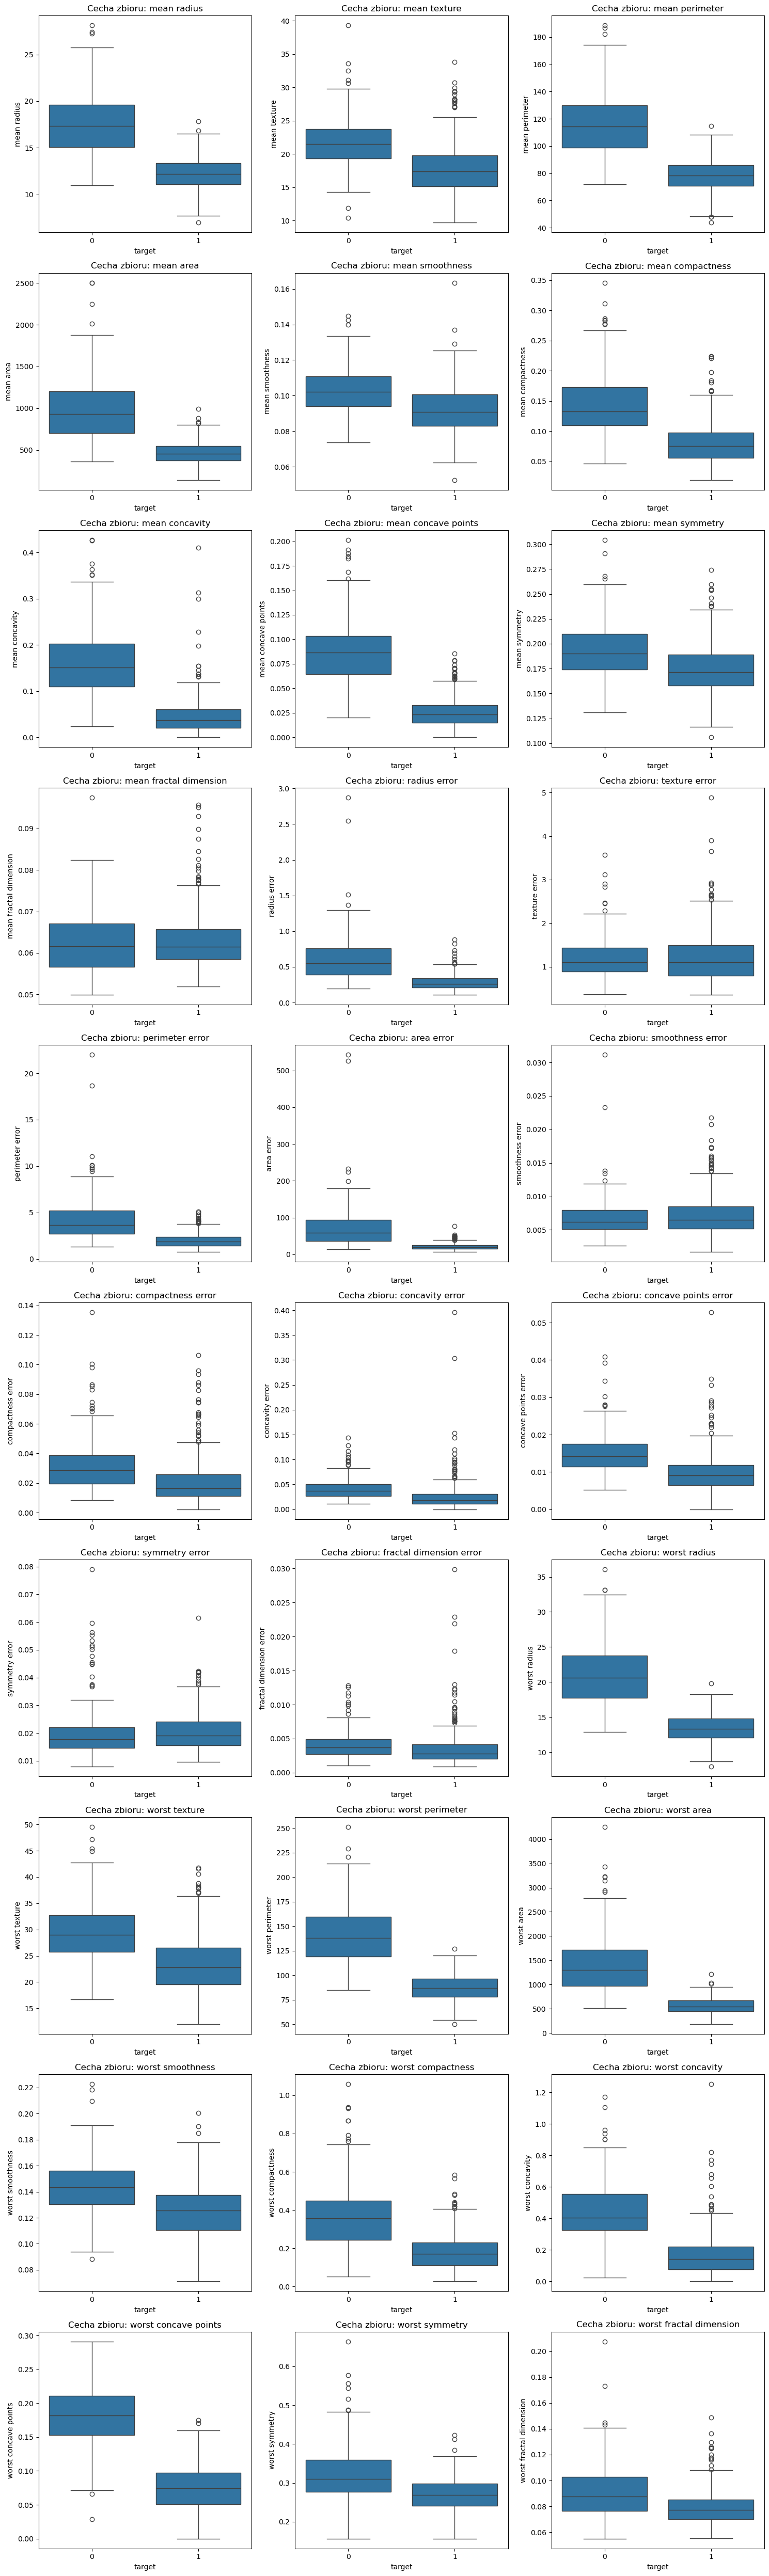

In [27]:
fig, ax = plt.subplots(math.ceil(len(X.columns)/3), 3, figsize=(15, math.ceil(len(X.columns)/3)*5))

for x in range(len(X.columns)):
    sns.boxplot(x='target', y=X.columns[x], data=df, ax=ax[math.floor(x/3), x%3])
    ax[math.floor(x/3), x%3].set_title(f'Cecha zbioru: {X.columns[x]}')

plt.tight_layout()
plt.show()

### Z pomocą poprzedniej metody widać, że możliwe jest stwierdzenie, które cechy mają większy, a które mniejszy wpływ na zmienną docelową (target). Można zauważyć, że pudełka (od Q1 do Q3) dla cech o większym wpływie znajdują się na innej wysokości i nie pokrywają tych samych danych, a cechy z mniejszym wpłwem nachodzą na siebie, tzn. są na tym samym poziomie. Metoda ta, więc pozwala ocenić wpływ cech na zmienną docelową, chociaż jest to trudniejsze, mniej dokładne, czasochłonne, zatem przy dużej ilości cech lepsza jest metoda z użyciem modelu Random Forest.

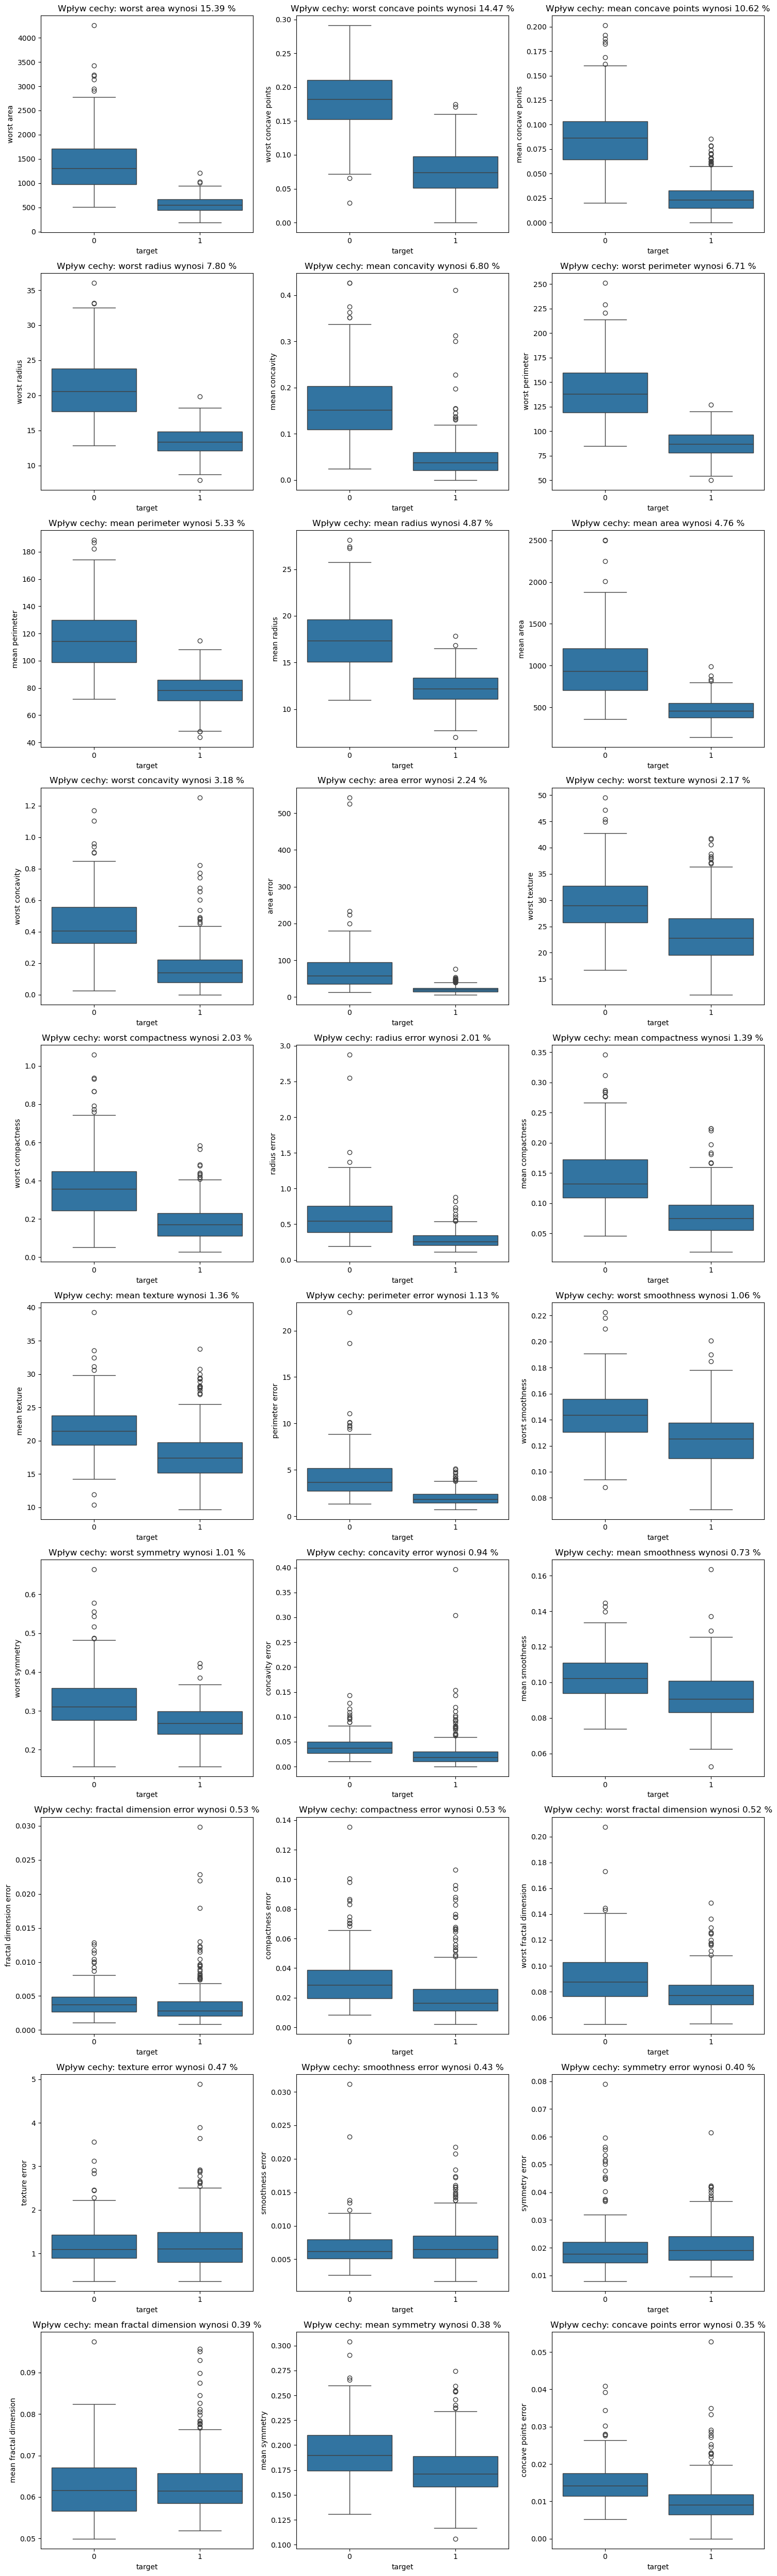

In [28]:
fig, ax = plt.subplots(math.ceil(len(X.columns)/3), 3, figsize=(15, math.ceil(len(X.columns)/3)*5))

for x in range(len(X.columns)):
    sns.boxplot(x='target', y=feature_importances_values_sorted_desc[x][0], data=df, ax=ax[math.floor(x/3), x%3])
    ax[math.floor(x/3), x%3].set_title(f'Wpływ cechy: {feature_importances_values_sorted_desc[x][0]} wynosi {(feature_importances_values_sorted_desc[x][1]*100):.2f} %')

plt.tight_layout()
plt.show()

# Regresja Logistyczna

## Użycie stratify=y sprawia, że przy podziale danych na treningowe i testowe pozostawia równe proporcje przypadków obu klas (target) w train i test przy podziale. Regresja logistyczna wykorzystuje wagi w modelu, więc potrzebne jest skalowanie danych.

In [29]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
X_train_scaled = X2_train.copy()
X_test_scaled = X2_test.copy()

columns_to_standardize = X.columns.tolist()
scaler = StandardScaler()
X_train_scaled[columns_to_standardize] = scaler.fit_transform(X2_train[columns_to_standardize])
X_test_scaled[columns_to_standardize] = scaler.transform(X2_test[columns_to_standardize])

In [31]:
model_logistic_regression = LogisticRegression(max_iter=1000)
model_logistic_regression.fit(X_train_scaled, y2_train)

LogisticRegression(max_iter=1000)

## Model Regresji Logistycznej dał wynik skuteczności 98%, więc jego skuteczność jest bardzo wysoka. Macierz pomyłek mówi, że model sklasyfikował tylko po jednym przypadku źle (jeden źle sklasyfikowany guz złośliwy i jeden źle sklasyfikowany guz łagodny).

In [32]:
y_pred_logistic_regression = model_logistic_regression.predict(X_test_scaled)

print('Dokładność (Accuracy Score):', accuracy_score(y2_test, y_pred_logistic_regression))
print('Macierz pomyłek (Confusion Matrix):', confusion_matrix(y2_test, y_pred_logistic_regression))
print('Raport', classification_report(y2_test, y_pred_logistic_regression))

Dokładność (Accuracy Score): 0.9824561403508771
Macierz pomyłek (Confusion Matrix): [[41  1]
 [ 1 71]]
Raport               precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# Kontynuacja Random Forest (z stratify=y)

In [33]:
model_random_forest_2 = RandomForestClassifier(n_estimators=100, random_state=42)
model_random_forest_2.fit(X2_train, y2_train)

RandomForestClassifier(random_state=42)

## Random Forest ma bardzo wysoką skuteczność 96%, choć trochę niższą niż Regresja Logistyczna. Model błędnie sklasyfikował 3 guzy jako złośliwe i 2 guzy jako łagodne.

In [34]:
y_pred_random_forest_2 = model_random_forest_2.predict(X2_test)

print('Dokładność (Accuracy Score):', accuracy_score(y2_test, y_pred_random_forest_2))
print('Macierz pomyłek (Confusion Matrix):', confusion_matrix(y2_test, y_pred_random_forest_2))
print('Raport', classification_report(y2_test, y_pred_random_forest_2))

Dokładność (Accuracy Score): 0.956140350877193
Macierz pomyłek (Confusion Matrix): [[39  3]
 [ 2 70]]
Raport               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [35]:
# https://www.geeksforgeeks.org/machine-learning/understanding-the-predictproba-function-in-scikit-learns-svc/
y_pred_proba_random_forest_2 = model_random_forest_2.predict_proba(X2_test)

for i, prob in enumerate(y_pred_proba_random_forest_2):
    print(f'Przykład {i+1}: Klasa 0 Prawdopodobieństwo = {prob[0]:.2f}, Klasa 1 Prawdopodobieństwo = {prob[1]:.2f}')

Przykład 1: Klasa 0 Prawdopodobieństwo = 1.00, Klasa 1 Prawdopodobieństwo = 0.00
Przykład 2: Klasa 0 Prawdopodobieństwo = 0.00, Klasa 1 Prawdopodobieństwo = 1.00
Przykład 3: Klasa 0 Prawdopodobieństwo = 0.88, Klasa 1 Prawdopodobieństwo = 0.12
Przykład 4: Klasa 0 Prawdopodobieństwo = 0.72, Klasa 1 Prawdopodobieństwo = 0.28
Przykład 5: Klasa 0 Prawdopodobieństwo = 0.99, Klasa 1 Prawdopodobieństwo = 0.01
Przykład 6: Klasa 0 Prawdopodobieństwo = 0.01, Klasa 1 Prawdopodobieństwo = 0.99
Przykład 7: Klasa 0 Prawdopodobieństwo = 0.05, Klasa 1 Prawdopodobieństwo = 0.95
Przykład 8: Klasa 0 Prawdopodobieństwo = 0.99, Klasa 1 Prawdopodobieństwo = 0.01
Przykład 9: Klasa 0 Prawdopodobieństwo = 1.00, Klasa 1 Prawdopodobieństwo = 0.00
Przykład 10: Klasa 0 Prawdopodobieństwo = 1.00, Klasa 1 Prawdopodobieństwo = 0.00
Przykład 11: Klasa 0 Prawdopodobieństwo = 0.02, Klasa 1 Prawdopodobieństwo = 0.98
Przykład 12: Klasa 0 Prawdopodobieństwo = 0.88, Klasa 1 Prawdopodobieństwo = 0.12
Przykład 13: Klasa 0 Praw

## Zmiana progu (threshold) na inne wartości. Podstawowy prób wynosi 0.5 i na podstawie tej wartości model podejmuje decyzje, który typ nowotworu to jest. Jeśli liczba jest powyżej progu to jest uznawana za nowotwór łagodny, a poniżej progu jest złośliwy. Zmiany progów mogą dać inne rezultaty. Tak jak widać przy zmianie progu, np. na 0.7 model wykrywa każdy nowotwór złośliwy i myli się 8 razy - klasyfikuje nowotwór jako złośliwy mimo, że jest łagodny, ale już nie klasyfikuje żadnego nowotworu złośliwego jako łagodny.

In [36]:
for x in np.arange(0.05, 1.0, 0.05):
    print(f'Próg (threshold): {x:.2f}')
    print(confusion_matrix(y2_test, (y_pred_proba_random_forest_2[:, 1] > x).astype(int)))

Próg (threshold): 0.05
[[33  9]
 [ 0 72]]
Próg (threshold): 0.10
[[35  7]
 [ 0 72]]
Próg (threshold): 0.15
[[37  5]
 [ 0 72]]
Próg (threshold): 0.20
[[37  5]
 [ 0 72]]
Próg (threshold): 0.25
[[37  5]
 [ 0 72]]
Próg (threshold): 0.30
[[37  5]
 [ 1 71]]
Próg (threshold): 0.35
[[38  4]
 [ 2 70]]
Próg (threshold): 0.40
[[39  3]
 [ 2 70]]
Próg (threshold): 0.45
[[39  3]
 [ 2 70]]
Próg (threshold): 0.50
[[39  3]
 [ 2 70]]
Próg (threshold): 0.55
[[39  3]
 [ 3 69]]
Próg (threshold): 0.60
[[40  2]
 [ 4 68]]
Próg (threshold): 0.65
[[41  1]
 [ 6 66]]
Próg (threshold): 0.70
[[42  0]
 [ 8 64]]
Próg (threshold): 0.75
[[42  0]
 [ 8 64]]
Próg (threshold): 0.80
[[42  0]
 [ 9 63]]
Próg (threshold): 0.85
[[42  0]
 [14 58]]
Próg (threshold): 0.90
[[42  0]
 [19 53]]
Próg (threshold): 0.95
[[42  0]
 [24 48]]


# Porównanie predykcji klasy 1 (bening - łagodny) modelów: Random Forest i Regresja Logistyczna za pomocą ROC Curve

In [37]:
y_pred_proba_logistic_regression = model_logistic_regression.predict_proba(X_test_scaled)

In [38]:
# https://www.geeksforgeeks.org/machine-learning/how-to-plot-roc-curve-in-python/
fpr_random_forest, tpr_random_forest, thresholds_random_forest = roc_curve(y2_test, y_pred_proba_random_forest_2[:, 1])
roc_auc_random_forest = auc(fpr_random_forest, tpr_random_forest)

fpr_logistic_regression, tpr_logistic_regression, thresholds_logistic_regression = roc_curve(y2_test, y_pred_proba_logistic_regression[:, 1])
roc_auc_logistic_regression = auc(fpr_logistic_regression, tpr_logistic_regression)

## ROC Curve pokazuje zbliżoną skuteczność modelu Random Forest i modelu Regresji Logistycznej. ROC Curve dla Random Forest dał prawie idealny wynik (0.99 - prawie doskonała klasyfikacja), a w przypadku Regresji Logistycznej model dał idealny wynik (1.00 - doskonała klasyfikacja). ROC Curve pokazuje (tak jak na wykresie) dla jakich progów (thresholds) jak dobrze działa model, zatem pozwala ocenić czy w razie potrzeby zmiana progów może poprawić działanie danego modelu.

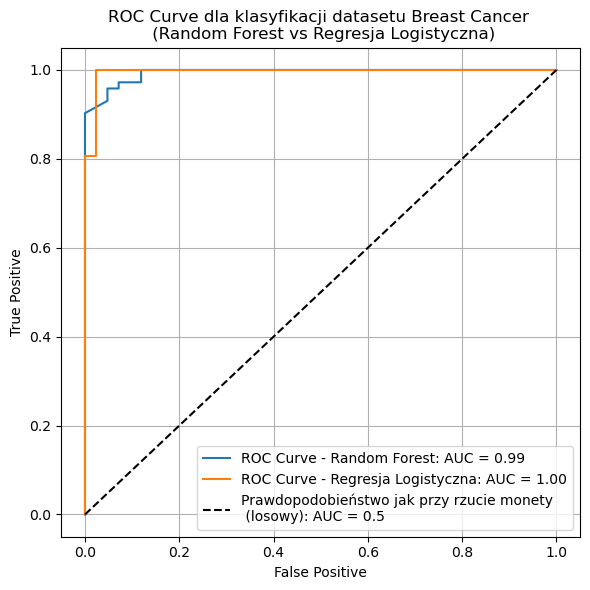

In [39]:
plt.figure(figsize=(6, 6))

plt.plot(fpr_random_forest, tpr_random_forest, label='ROC Curve - Random Forest: AUC = %0.2f' % roc_auc_random_forest)
plt.plot(fpr_logistic_regression, tpr_logistic_regression, label='ROC Curve - Regresja Logistyczna: AUC = %0.2f' % roc_auc_logistic_regression)
plt.plot([0, 1], [0, 1], 'k--', label='Prawdopodobieństwo jak przy rzucie monety \n (losowy): AUC = 0.5')

plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC Curve dla klasyfikacji datasetu Breast Cancer \n (Random Forest vs Regresja Logistyczna)')
plt.grid()
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()